In [1]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

In [3]:
def r_scatter(r):
    "Generate a scatter plot with a correlation approximately r"
    plots.figure(figsize=(5,5))
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    plots.scatter(x, y, color='darkblue', s=20)
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)

# Lecture 29 Correlation

## Approach to Prediction

Predication is based on data.

Using an existing sample we can make predictions of an overall situation by evaluating the average of all those that meet the same criteria. 

One way to predict an outcome for an individual is to find others who are like that individual and whose outcomes you know.</br>
Use those outcomes as the basis of your prediction.

In [4]:
# Note: Child heights are the **adult** heights of children in a family
families = Table.read_table('family_heights.csv')
families

family,father,mother,child,children,order,sex
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female
2,75.5,66.5,73.5,4,1,male
2,75.5,66.5,72.5,4,2,male
2,75.5,66.5,65.5,4,3,female
2,75.5,66.5,65.5,4,4,female
3,75,64,71,2,1,male
3,75,64,68,2,2,female


In [5]:
# Takes the average of the height of the mother and father. 

parent_avgs = (families.column('father') + families.column('mother'))/2

In [9]:
# COMPLETE: Create a table with two columns: 'Parent Average' and 'Child' which holds the individual child's height. 
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child')
)

# Alternative Way
# heights = families.with_column('Parent Average', parent_avgs).select('Parent Average', 'child').relabeled('child', 'Child')

heights

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


***QUESTION: How would you describe the scatterplot below?***

Describe it

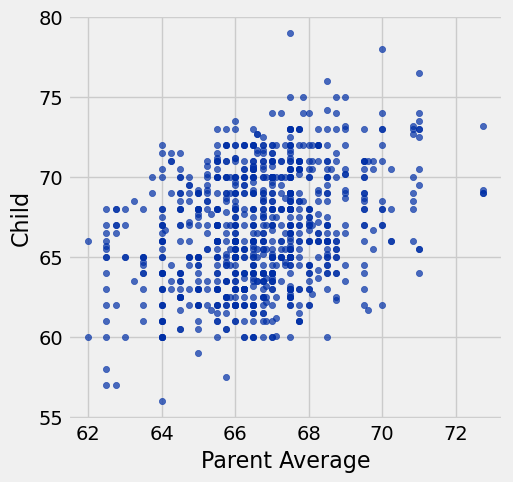

In [10]:
# Plot a scatter comparing Parent Average with Child height.

heights.scatter('Parent Average', 'Child')

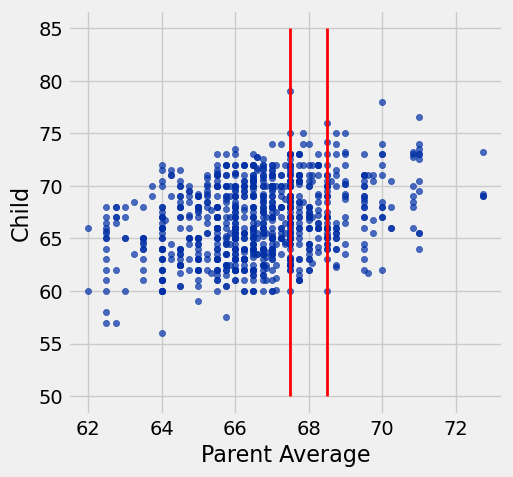

In [11]:
# Focus on the grouping of child heights between the parent averages of 67.5 and 68.5.

heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2);

In [13]:
# Calculate the average of all the children in the focused grouping. 

nearby = heights.where('Parent Average', are.between(67.5, 68.5))
nearby_mean = np.average(nearby.column('Child'))
nearby_mean

67.620000000000005

***QUESTION: What is happening in this scatterplot?***

This is the predicted average height for a child with parent's in this height range.

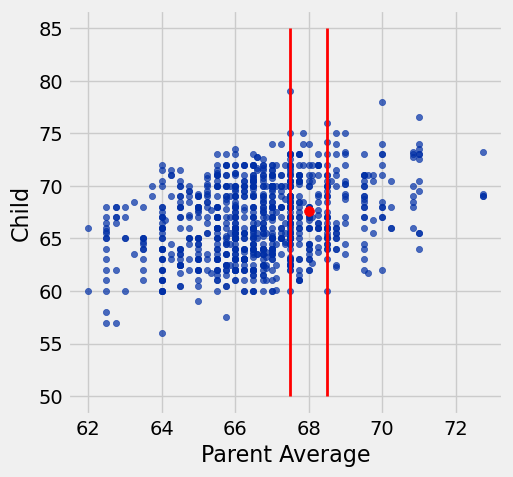

In [15]:
#Plot the new average. 

heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, nearby_mean, color='red', s=50);

In [18]:
# COMPLETE: Finish the function below
def predict_child( h ):
    """Predict the height of a child whose parents have a parent average height of p_avg.
    
    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    nearby = heights.where('Parent Average', are.between(h - 0.5, h + 0.5))
    return np.mean(nearby.column('Child'))

In [20]:
# Find all the predicted heights of children with parent's with different average heights. 

heights_with_predictions = heights.with_columns(
    'Prediction', heights.apply(predict_child, 'Parent Average'))
heights_with_predictions

Parent Average,Child,Prediction
72.75,73.2,70.1
72.75,69.2,70.1
72.75,69,70.1
72.75,69,70.1
71,73.5,70.4158
71,72.5,70.4158
71,65.5,70.4158
71,65.5,70.4158
69.5,71,68.5025
69.5,68,68.5025


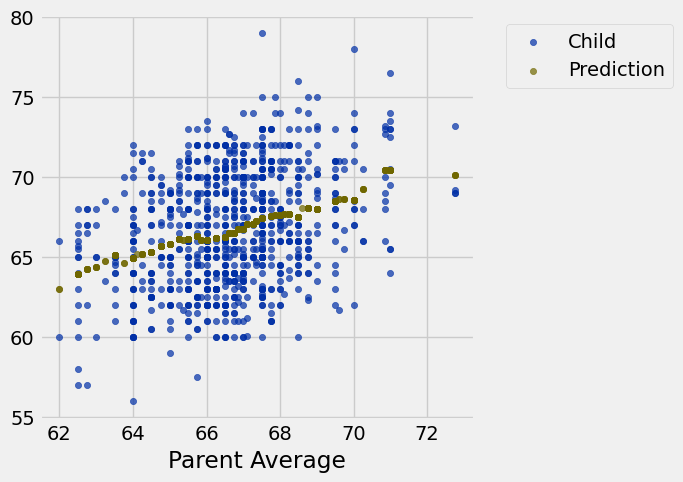

In [21]:
# Plot all the new predictions

heights_with_predictions.scatter('Parent Average')

## Association

Establishing a relationship between variables. 
Look for a pattern in the graph: Linear or Non-Linear.

1. Load the data about hybrid data. <br>
2. Describe the table.

?

In [23]:
# Load in data about hybrid vehicles. 

hybrid = Table.read_table('hybrid.csv')
hybrid

vehicle,year,msrp,acceleration,mpg,class
Prius (1st Gen),1997,24509.7,7.46,41.26,Compact
Tino,2000,35355,8.2,54.1,Compact
Prius (2nd Gen),2000,26832.2,7.97,45.23,Compact
Insight,2000,18936.4,9.52,53,Two Seater
Civic (1st Gen),2001,25833.4,7.04,47.04,Compact
Insight,2001,19036.7,9.52,53,Two Seater
Insight,2002,19137,9.71,53,Two Seater
Alphard,2003,38084.8,8.33,40.46,Minivan
Insight,2003,19137,9.52,53,Two Seater
Civic,2003,14071.9,8.62,41,Compact


In [24]:
# COMPLETE: Sort the table by MSRP from greatest to least. Do not reassign.
hybrid.sort('msrp', descending=True)


vehicle,year,msrp,acceleration,mpg,class
Lexus LS600h/hL,2007,118544,17.54,21,Midsize
ActiveHybrid 7,2010,104300,20.41,22.11,Large
ActiveHybrid 7i,2011,102606,18.18,20,Midsize
ActiveHybrid X6,2009,97237.9,17.96,18.82,SUV
S400 Long,2009,96208.9,13.89,26.34,Large
Panamera S,2013,96150,18.52,25,Large
Panamera S,2012,95283.9,17.54,25,Large
S400,2013,92350,13.89,21,Large
S400,2010,88212.8,12.99,21,Large
ActiveHybrid 7L,2013,84300,18.18,25,Large


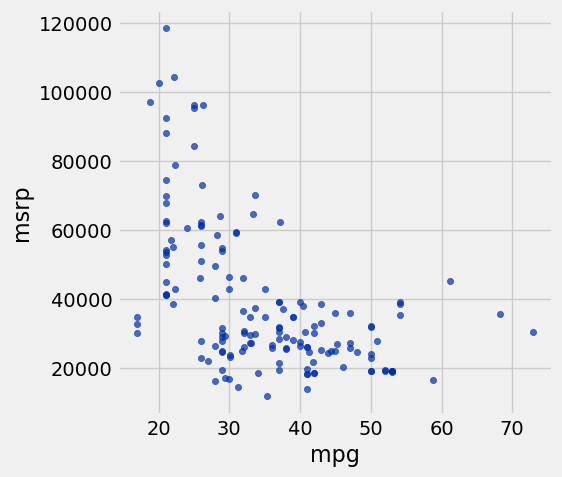

In [25]:
# COMPLETE: Compare the hybrid mpg with the msrp on a scatter plot. 

hybrid.scatter('mpg', 'msrp')

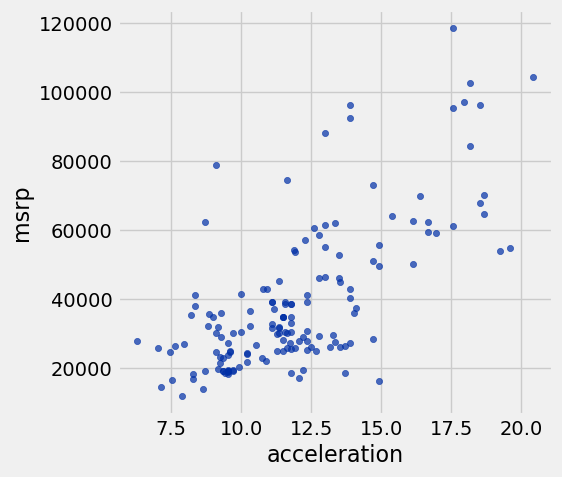

In [26]:
# COMPLETE: Compare the hybrid accerleration with the msrp on a scatter plot. 

hybrid.scatter('acceleration', 'msrp')

In [27]:
# COMPLETE: Create a table with just hybrids that are SUV. 
suv = hybrid.where('class', 'SUV')
suv

vehicle,year,msrp,acceleration,mpg,class
Escape,2004,36676.1,10.32,31.99,SUV
Lexus RX400h,2005,58521.1,12.76,28.23,SUV
Highlander,2005,29186.2,12.76,29.4,SUV
Escape 2WD,2005,19322.6,9.52,29,SUV
Mercury Mariner,2006,34772.4,8.98,32.93,SUV
Chevrolet Tahoe,2007,42924.3,10.91,22.35,SUV
Kluger,2007,46229.5,12.76,25.87,SUV
Tribute,2007,24823.8,11.28,31.75,SUV
GMC Yukon,2007,57094.8,12.28,21.78,SUV
Vue,2007,22938.3,10.75,26,SUV


In [28]:
# COMPLETE: Determine how many hybrids are in that table. 
suv.num_rows


39

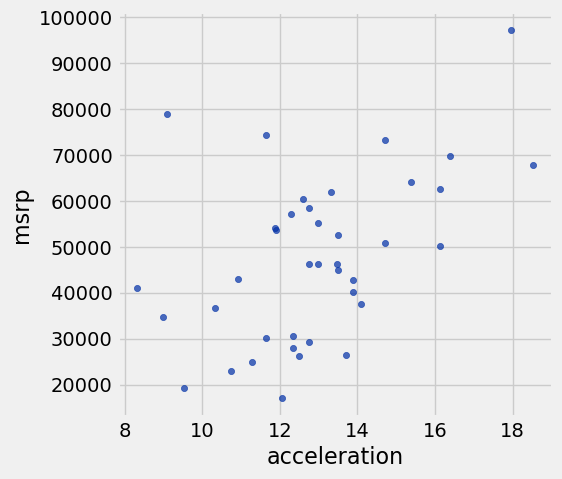

In [29]:
# COMPLETE: Compare the hybrid SUVs acceleration with the msrp on a scatter plot. 

suv.scatter('acceleration', 'msrp')

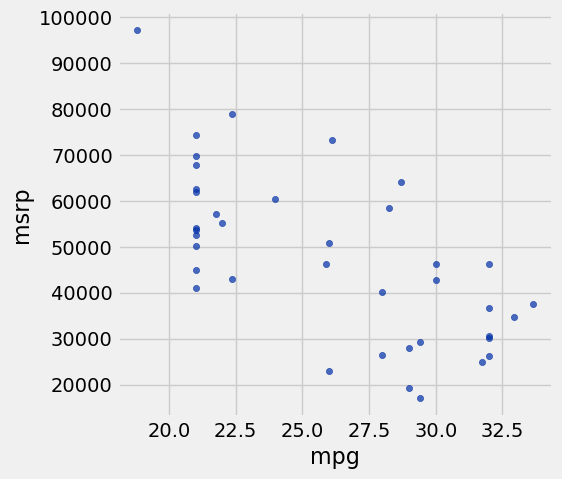

In [30]:
# COMPLETE: Compare the hybrid SUVs mpg with the msrp on a scatter plot. 

suv.scatter('mpg', 'msrp')

***QUESTION: What is the difference between the SUV scatter verses the scatter for the entire population?***



In [31]:
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x)) / np.std(x)

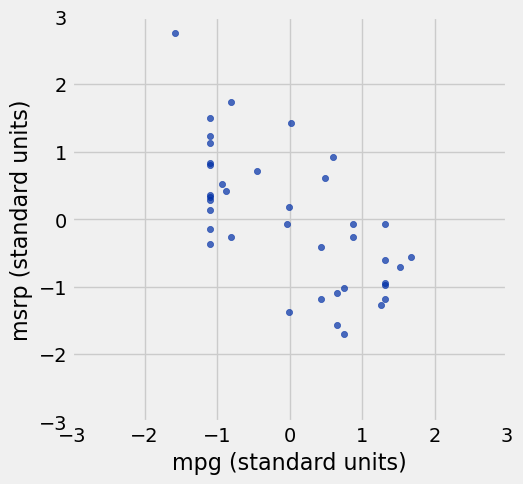

In [32]:
# View the data using standard units. 

Table().with_columns(
    'mpg (standard units)',  standard_units(suv.column('mpg')), 
    'msrp (standard units)', standard_units(suv.column('msrp'))
).scatter(0, 1)
plots.xlim(-3, 3)
plots.ylim(-3, 3);

***QUESTION What do you notice with the scatter?***

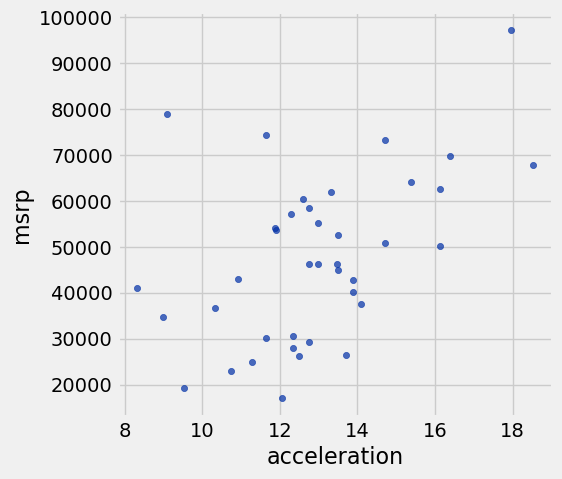

In [33]:
# Compare the hybrid SUVs acceleration with the msrp on a scatter plot. 

suv.scatter('acceleration', 'msrp')

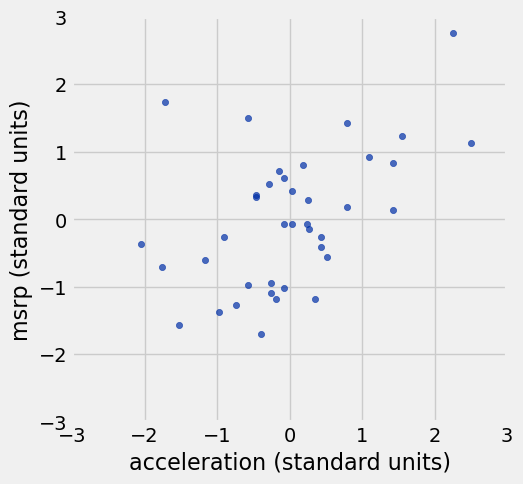

In [34]:
#View the data in standard units. 

Table().with_columns(
    'acceleration (standard units)', standard_units(suv.column('acceleration')), 
    'msrp (standard units)',         standard_units(suv.column('msrp'))
).scatter(0, 1)
plots.xlim(-3, 3)
plots.ylim(-3, 3);

***QUESTION: What do you notice when you compare the two scatter plots?***

## Correlation
An association that is linear is referred to as correlation. 
A correlation coefficient, r, can measure the strength and direction of a linear relationship. </br>
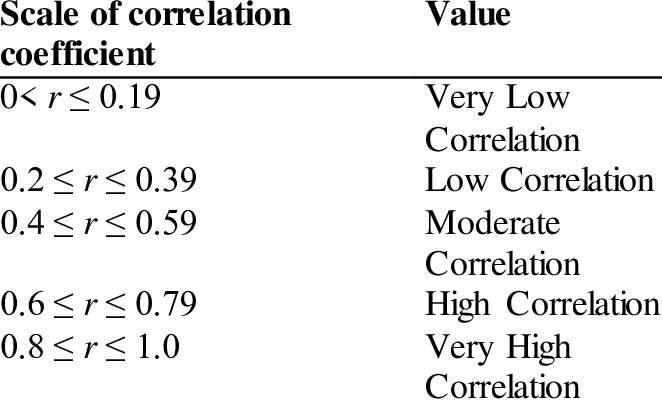

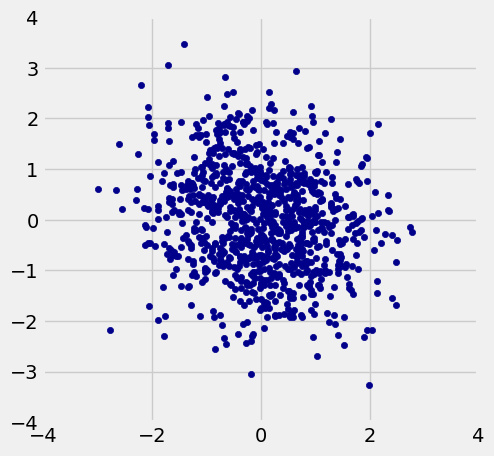

In [35]:
r_scatter(-0.2)

In [36]:
x = np.arange(1, 7, 1)
y = make_array(2, 3, 1, 5, 2, 7)
t = Table().with_columns(
        'x', x,
        'y', y 
    )
t

x,y
1,2
2,3
3,1
4,5
5,2
6,7


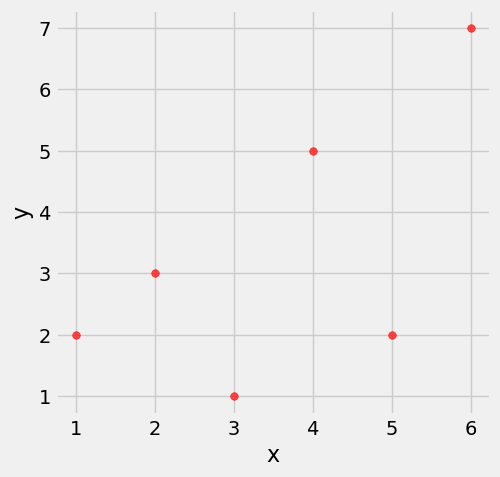

In [37]:
t.scatter('x', 'y', s=30, color='red')

In [38]:
t = t.with_columns(
        'x (standard units)', standard_units(x),
        'y (standard units)', standard_units(y) 
    )
t

x,y,x (standard units),y (standard units)
1,2,-1.46385,-0.648886
2,3,-0.87831,-0.162221
3,1,-0.29277,-1.13555
4,5,0.29277,0.811107
5,2,0.87831,-0.648886
6,7,1.46385,1.78444


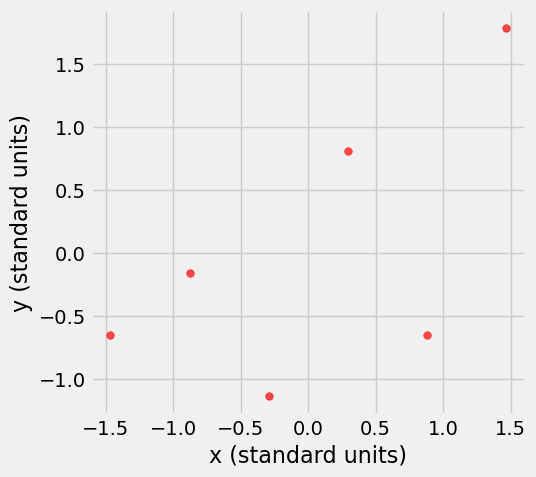

In [39]:
t.scatter('x (standard units)', 'y (standard units)', s=30, color='red')

In [40]:
t = t.with_columns(
    'product of standard units', t.column(2) * t.column(3))
t

x,y,x (standard units),y (standard units),product of standard units
1,2,-1.46385,-0.648886,0.949871
2,3,-0.87831,-0.162221,0.142481
3,1,-0.29277,-1.13555,0.332455
4,5,0.29277,0.811107,0.237468
5,2,0.87831,-0.648886,-0.569923
6,7,1.46385,1.78444,2.61215


In [41]:
# r is the average of the products of the standard units
r = np.average(t.column(2) * t.column(3))
r

0.61741639718977093

In [42]:
# Average of column 'product of standard units'
r = np.average(t.column(4))
r

0.61741639718977093

In [43]:
def correlation(t, x, y):
    """t is a table; x and y are column labels"""
    x_in_standard_units = standard_units(t.column(x))
    y_in_standard_units = standard_units(t.column(y))
    return np.average(x_in_standard_units * y_in_standard_units)

In [44]:
correlation(t, 'x', 'y')

0.61741639718977093

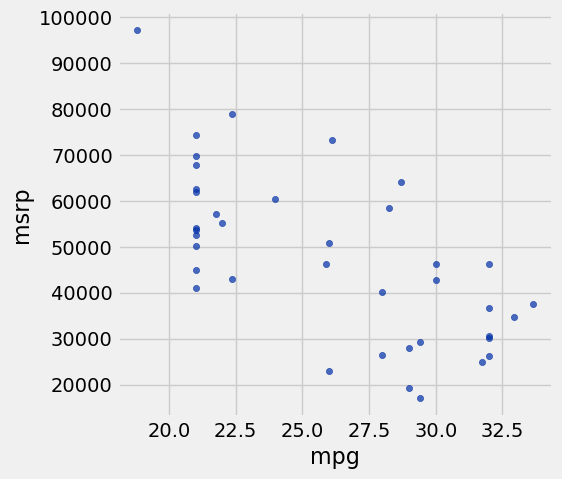

In [45]:
suv.scatter('mpg', 'msrp')

In [46]:
correlation(suv, 'mpg', 'msrp')

-0.6667143635709919

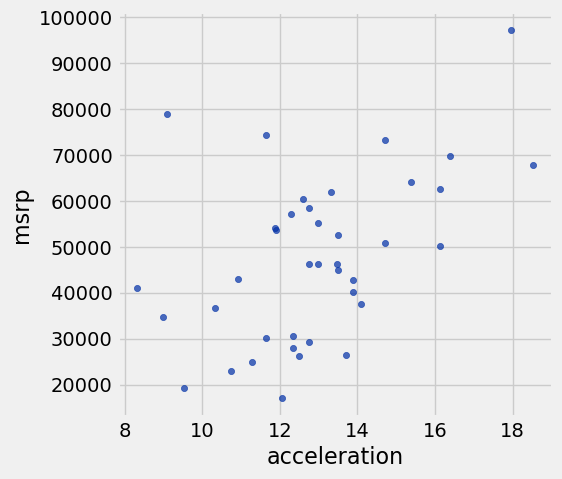

In [47]:
suv.scatter('acceleration', 'msrp')

In [48]:
correlation(suv, 'acceleration', 'msrp')

0.48699799279959155

### Switching Axes

In [49]:
correlation(t, 'x', 'y')

0.61741639718977093

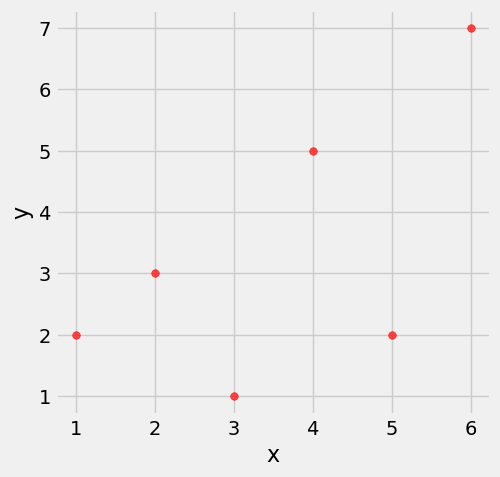

In [50]:
t.scatter('x', 'y', s=30, color='red')

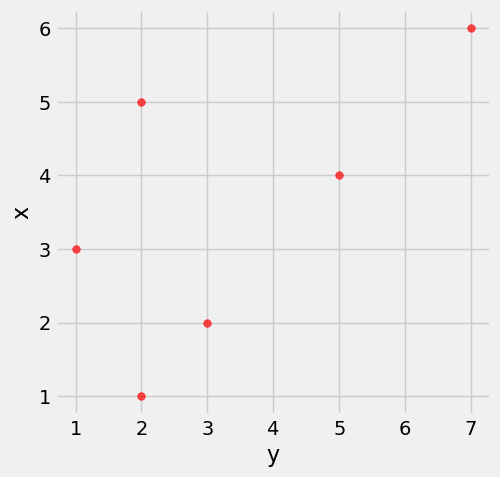

In [51]:
t.scatter('y', 'x', s=30, color='red')

In [52]:
correlation(t, 'y', 'x')

0.61741639718977093

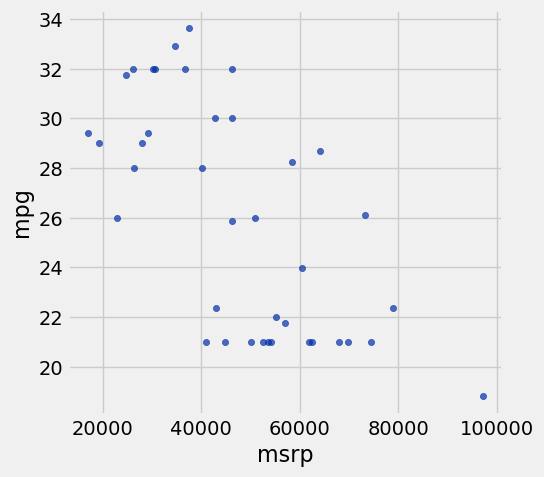

In [53]:
suv.scatter('msrp', 'mpg')

In [54]:
correlation(suv, 'msrp', 'mpg')

-0.6667143635709919

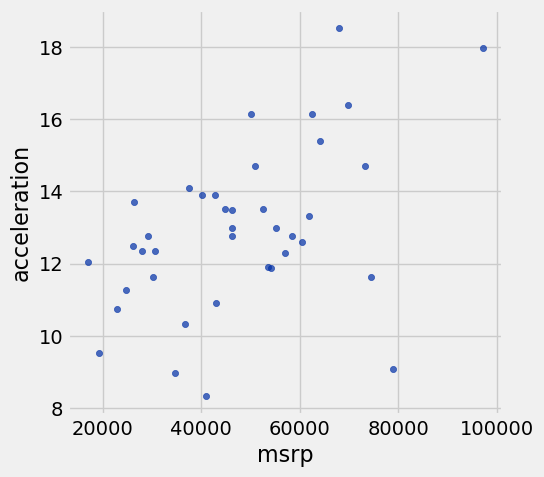

In [55]:
suv.scatter( 'msrp', 'acceleration')

In [56]:
correlation(suv, 'msrp', 'acceleration')

0.48699799279959155